# 03 Model Training

En este notebook se entrenan diferentes modelos de clasificación para predecir la probabilidad de abandono (`Churn`) de los clientes.

El entrenamiento se realiza sobre el conjunto de entrenamiento generado durante la fase de preprocesamiento.

Se comenzará estableciendo un modelo baseline como referencia y posteriormente se entrenarán otros modelos de clasificación supervisada más avanzados.

In [59]:
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix

## 1. Carga de datos procesados

Se cargan los conjuntos de entrenamiento y test generados durante la fase de preprocesamiento.

El conjunto de entrenamiento se utilizará para ajustar los modelos, mientras que el conjunto de test permanecerá reservado para la evaluación final.

In [2]:
PROCESSED_DATA_PATH = "../data/processed"

X_train = pd.read_csv(
    f"{PROCESSED_DATA_PATH}/X_train.csv"
)

X_test = pd.read_csv(
    f"{PROCESSED_DATA_PATH}/X_test.csv"
)

y_train = pd.read_csv(
    f"{PROCESSED_DATA_PATH}/y_train.csv"
).squeeze("columns")

y_test = pd.read_csv(
    f"{PROCESSED_DATA_PATH}/y_test.csv"
).squeeze("columns")

In [3]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nTipo X_train:", type(X_train))
print("Tipo y_train:", type(y_train))

X_train: (5634, 26)
X_test: (1409, 26)
y_train: (5634,)
y_test: (1409,)

Tipo X_train: <class 'pandas.DataFrame'>
Tipo y_train: <class 'pandas.Series'>


## 2. Modelo baseline

Antes de entrenar modelos de clasificación más complejos, se establece un modelo baseline.

El objetivo del baseline es proporcionar una referencia mínima con la que comparar posteriormente el rendimiento de los modelos entrenados.

Para ello se utiliza `DummyClassifier`, que genera predicciones siguiendo una estrategia simple y sin aprender relaciones entre las variables predictoras y la variable objetivo.

### 2.1 Entrenamiento del baseline

Se utiliza `DummyClassifier` con la estrategia `most_frequent`.

Esta estrategia predice siempre la clase más frecuente observada en el conjunto de entrenamiento. En este problema, la clase mayoritaria corresponde a los clientes que no realizan churn (`Churn = 0`).

Este modelo no utiliza las variables predictoras para aprender patrones. Su objetivo es establecer una referencia mínima frente a la que comparar posteriormente los modelos supervisados.

In [4]:
dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.73,0.27]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](26,)","['gender','SeniorCitizen','Partner',..., 'PaymentMethod_Credit card (automatic)','PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,26
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [5]:
print("Clases:", dummy_model.classes_)
print("Clase más frecuente:", dummy_model.class_prior_)

Clases: [0 1]
Clase más frecuente: [0.73464679 0.26535321]


### 2.2 Evaluación del baseline

In [6]:
y_train_pred_dummy = dummy_model.predict(X_train)

In [7]:
pd.Series(y_train_pred_dummy).value_counts()

0    5634
Name: count, dtype: int64

In [8]:
dummy_accuracy = accuracy_score(
    y_train,
    y_train_pred_dummy
)

dummy_precision = precision_score(
    y_train,
    y_train_pred_dummy,
    zero_division=0
)

dummy_recall = recall_score(
    y_train,
    y_train_pred_dummy,
    zero_division=0
)

dummy_f1 = f1_score(
    y_train,
    y_train_pred_dummy,
    zero_division=0
)

print(f"Accuracy:  {dummy_accuracy:.4f}")
print(f"Precision: {dummy_precision:.4f}")
print(f"Recall:    {dummy_recall:.4f}")
print(f"F1-score:  {dummy_f1:.4f}")

Accuracy:  0.7346
Precision: 0.0000
Recall:    0.0000
F1-score:  0.0000


### 2.3 Resultados del baseline

El modelo baseline obtiene una accuracy ligeramente superior al 73 %, debido a que predice siempre la clase mayoritaria (`Churn = 0`).

Sin embargo, obtiene valores de 0 en precision, recall y F1-score para la clase positiva, ya que no identifica ningún cliente que realiza churn.

Este resultado muestra que la accuracy, utilizada de forma aislada, no es una métrica suficiente para evaluar este problema de clasificación.

## 3. Logistic Regression

### 3.1 Pipeline de entrenamiento

Las variables numéricas continuas `tenure`, `MonthlyCharges` y `TotalCharges` se estandarizan mediante `StandardScaler`.

Las variables binarias no requieren escalado y se mantienen sin modificar.

El preprocesamiento específico del modelo y la regresión logística se integran en un `Pipeline`, permitiendo que las transformaciones se ajusten conjuntamente durante el entrenamiento.

In [9]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

In [10]:
logistic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        )
    ],
    remainder="passthrough"
)

In [11]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", logistic_preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [12]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](26,)","['gender','SeniorCitizen','Partner',..., 'PaymentMethod_Credit card (automatic)','PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,26
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (de

### 3.2 Validación cruzada

El rendimiento de la regresión logística se estima mediante validación cruzada estratificada sobre el conjunto de entrenamiento.

Se utiliza `StratifiedKFold` con 5 particiones para mantener aproximadamente la distribución de la variable objetivo en cada fold.

El conjunto de test permanece completamente reservado para la evaluación final del modelo seleccionado.

In [13]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [14]:
scoring = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "average_precision"
]

In [15]:
logistic_cv_results = cross_validate(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [16]:
logistic_cv_results_df = pd.DataFrame({
    "Accuracy": logistic_cv_results["test_accuracy"],
    "Precision": logistic_cv_results["test_precision"],
    "Recall": logistic_cv_results["test_recall"],
    "F1": logistic_cv_results["test_f1"],
    "ROC-AUC": logistic_cv_results["test_roc_auc"],
    "Average Precision": logistic_cv_results["test_average_precision"]

})

logistic_cv_results_df

,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0,0.798580,0.645161,0.535117,0.585009,0.847721,0.643613
1,0.781721,0.607287,0.501672,0.549451,0.825188,0.635536
2,0.802130,0.658333,0.528428,0.586271,0.841812,0.685467
3,0.816327,0.664286,0.622074,0.642487,0.862640,0.677341
4,0.812611,0.692982,0.528428,0.599620,0.852984,0.664626


In [17]:
logistic_cv_results_df.agg(["mean", "std"])

,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
mean,0.802274,0.65361,0.543144,0.592568,0.846069,0.661317
std,0.013605,0.03124,0.045955,0.033532,0.013958,0.021383


### 3.3 Resultados de validación cruzada

La regresión logística obtiene un ROC-AUC medio de aproximadamente 0.846 y una accuracy media de 0.802 durante la validación cruzada.

El modelo alcanza una precision media de 0.654 y un recall de 0.543 para la clase positiva. Esto indica que, utilizando el umbral de clasificación por defecto, el modelo identifica algo más de la mitad de los clientes que realizan churn.

El F1-score medio es de 0.593, reflejando el equilibrio entre precision y recall.

Las desviaciones estándar obtenidas entre los cinco folds son relativamente reducidas, lo que indica que el rendimiento del modelo es estable entre las diferentes particiones del conjunto de entrenamiento.

Estos resultados se utilizarán como referencia para comparar posteriormente otros algoritmos de clasificación.

## 4. Random Forest

### 4.1 Entrenamiento y validación cruzada

Random Forest permite capturar relaciones no lineales e interacciones entre las variables sin necesidad de especificarlas explícitamente.

Al tratarse de un modelo basado en árboles, no requiere la estandarización de las variables numéricas. Su rendimiento se evaluará utilizando la misma estrategia de validación cruzada estratificada empleada con Logistic Regression.

In [18]:
random_forest_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

In [19]:
random_forest_cv_results = cross_validate(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [20]:
random_forest_cv_results_df = pd.DataFrame({
    "Accuracy": random_forest_cv_results["test_accuracy"],
    "Precision": random_forest_cv_results["test_precision"],
    "Recall": random_forest_cv_results["test_recall"],
    "F1": random_forest_cv_results["test_f1"],
    "ROC-AUC": random_forest_cv_results["test_roc_auc"],
    "Average Precision": random_forest_cv_results["test_average_precision"]
})

random_forest_cv_results_df

,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0,0.781721,0.611814,0.484950,0.541045,0.817429,0.584078
1,0.773736,0.595652,0.458194,0.517958,0.806561,0.593990
2,0.807453,0.670833,0.538462,0.597403,0.829367,0.638812
3,0.781721,0.615721,0.471572,0.534091,0.819772,0.610968
4,0.799290,0.671362,0.478261,0.558594,0.841689,0.646696


In [21]:
random_forest_cv_results_df.agg(["mean", "std"])

,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
mean,0.788784,0.633076,0.486288,0.549818,0.822964,0.614909
std,0.014010,0.035515,0.030798,0.030334,0.013243,0.027319


### 4.2 Resultados de validación cruzada

Random Forest obtiene un ROC-AUC medio de aproximadamente 0.823 y una accuracy media de 0.789.

El modelo alcanza una precision media de 0.633, un recall de 0.486 y un F1-score de 0.550.

En comparación con la regresión logística, Random Forest obtiene resultados inferiores en las métricas evaluadas con su configuración inicial. En particular, presenta una menor capacidad para identificar clientes que realizan churn, reflejada en un recall inferior.

Estos resultados corresponden a la configuración base del modelo y no incluyen todavía optimización de hiperparámetros.

## 5. XGBoost

### 5.1 Entrenamiento y validación cruzada

XGBoost es un algoritmo de boosting basado en árboles de decisión.

A diferencia de Random Forest, donde múltiples árboles se construyen de forma relativamente independiente, XGBoost construye los árboles de manera secuencial. Cada nuevo árbol trata de mejorar los errores cometidos por el conjunto de árboles anteriores.

Al tratarse de un modelo basado en árboles, no requiere la estandarización de las variables numéricas.

In [22]:
xgboost_model = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

In [23]:
xgboost_cv_results = cross_validate(
    xgboost_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [24]:
xgboost_cv_results

{'fit_time': array([0.77888155, 0.72314334, 0.77655745, 0.72190166, 0.69630837]),
 'score_time': array([0.05185914, 0.05437136, 0.053473  , 0.04933596, 0.06001544]),
 'test_accuracy': array([0.7905945 , 0.77373558, 0.78793256, 0.7826087 , 0.80461812]),
 'test_precision': array([0.62650602, 0.58730159, 0.61538462, 0.60546875, 0.6695279 ]),
 'test_recall': array([0.52173913, 0.49498328, 0.53511706, 0.51839465, 0.52173913]),
 'test_f1': array([0.56934307, 0.53720508, 0.57245081, 0.55855856, 0.58646617]),
 'test_roc_auc': array([0.82152667, 0.81513661, 0.8171744 , 0.82708465, 0.83300846]),
 'test_average_precision': array([0.61326819, 0.62171323, 0.63873315, 0.62132637, 0.64089004])}

In [25]:
xgboost_cv_results_df = pd.DataFrame({
    "Accuracy": xgboost_cv_results["test_accuracy"],
    "Precision": xgboost_cv_results["test_precision"],
    "Recall": xgboost_cv_results["test_recall"],
    "F1": xgboost_cv_results["test_f1"],
    "ROC-AUC": xgboost_cv_results["test_roc_auc"],
    "Average Precision": xgboost_cv_results["test_average_precision"]
})

xgboost_cv_results_df

,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0,0.790594,0.626506,0.521739,0.569343,0.821527,0.613268
1,0.773736,0.587302,0.494983,0.537205,0.815137,0.621713
2,0.787933,0.615385,0.535117,0.572451,0.817174,0.638733
3,0.782609,0.605469,0.518395,0.558559,0.827085,0.621326
4,0.804618,0.669528,0.521739,0.586466,0.833008,0.640890


In [26]:
xgboost_cv_results_df.agg(["mean", "std"])

,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
mean,0.787898,0.620838,0.518395,0.564805,0.822786,0.627186
std,0.011351,0.030796,0.014578,0.018365,0.007324,0.012033


### 5.2 Resultados de validación cruzada

XGBoost obtiene una accuracy media de aproximadamente 0.788 y un ROC-AUC medio de 0.823.

Para la clase positiva, el modelo alcanza una precision media de 0.621, un recall de 0.518 y un F1-score de 0.565.

La desviación estándar de las métricas es relativamente reducida entre los cinco folds, especialmente en ROC-AUC, lo que indica un comportamiento estable entre las diferentes particiones del conjunto de entrenamiento.

Estos resultados corresponden a la configuración inicial del modelo, sin optimización de hiperparámetros.

### 6. Comparación de modelos iniciales

Los tres modelos se han evaluado utilizando el mismo procedimiento de validación cruzada estratificada sobre el conjunto de entrenamiento.

En sus configuraciones iniciales, Logistic Regression presenta los valores medios más altos en las métricas evaluadas, alcanzando un ROC-AUC aproximado de 0.846 y un F1-score de 0.593.

Random Forest y XGBoost obtienen resultados similares en ROC-AUC, alrededor de 0.823. XGBoost presenta un recall superior a Random Forest, mientras que Random Forest obtiene una precision ligeramente superior.

Estos resultados representan una comparación inicial y no determinan todavía el modelo final, ya que los modelos no han sido sometidos a optimización de hiperparámetros.

In [27]:
model_comparison = pd.DataFrame({
    "Logistic Regression": logistic_cv_results_df.mean(),
    "Random Forest": random_forest_cv_results_df.mean(),
    "XGBoost": xgboost_cv_results_df.mean()
}).T

model_comparison

,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
Logistic Regression,0.802274,0.653610,0.543144,0.592568,0.846069,0.661317
Random Forest,0.788784,0.633076,0.486288,0.549818,0.822964,0.614909
XGBoost,0.787898,0.620838,0.518395,0.564805,0.822786,0.627186


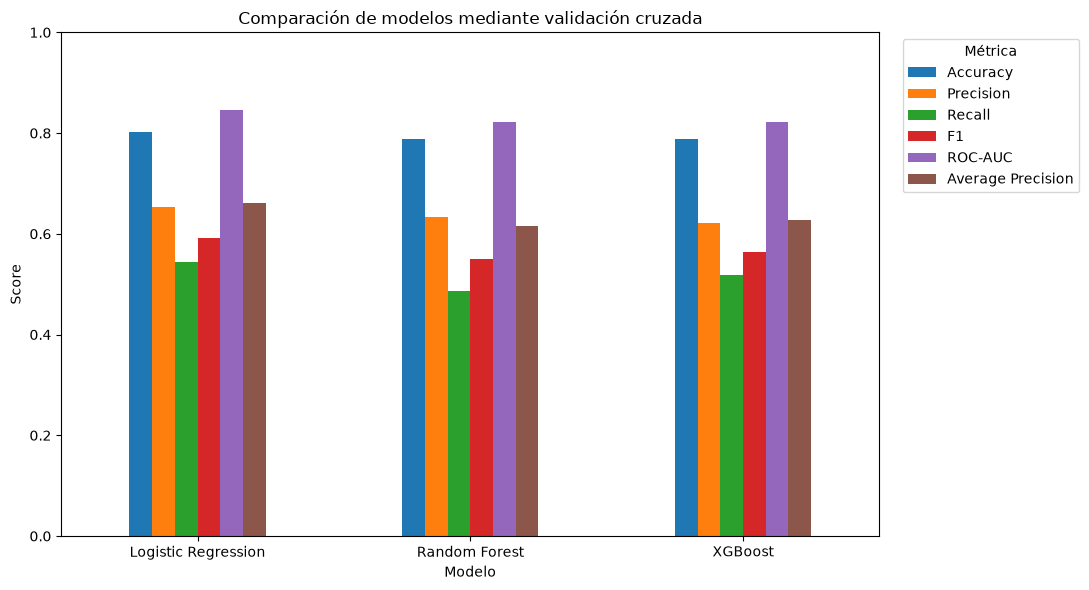

In [ ]:
ax = model_comparison.plot(
    kind="bar",
    figsize=(11, 6)
)

ax.set_title("Comparación de modelos mediante validación cruzada")
ax.set_xlabel("Modelo")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(title="Métrica", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

La comparación de las métricas medias obtenidas mediante validación cruzada permite observar las diferencias entre los modelos en sus configuraciones iniciales.

Logistic Regression presenta los valores medios más altos en las seis métricas evaluadas. Random Forest y XGBoost muestran un rendimiento similar en ROC-AUC, aunque XGBoost obtiene un recall superior a Random Forest y Random Forest una precision ligeramente superior.

Estos resultados constituyen únicamente una comparación inicial y no determinan todavía el modelo seleccionado, ya que los modelos aún no han sido sometidos a optimización de hiperparámetros.

## 7. Optimización de hiperparámetros

Una vez evaluados los modelos en sus configuraciones iniciales, se realiza una optimización de hiperparámetros utilizando exclusivamente el conjunto de entrenamiento.

La búsqueda se realiza mediante validación cruzada estratificada, manteniendo el conjunto de test reservado para la evaluación final.

En el escenario de negocio planteado se considera más costoso no detectar a un cliente que finalmente realiza churn (falso negativo) que identificar como posible churn a un cliente que finalmente permanece (falso positivo). Por este motivo, el recall tendrá especial importancia en la evaluación final.

Sin embargo, el recall depende del threshold utilizado para transformar las probabilidades estimadas en clases. Optimizar directamente esta métrica condicionaría la selección de hiperparámetros al threshold por defecto de 0.5.

Por este motivo, se utiliza Average Precision como métrica principal durante la optimización. Esta métrica permite evaluar la capacidad del modelo para priorizar la clase positiva considerando la relación entre precision y recall a través de diferentes thresholds.

De esta forma se separa la selección del modelo de la posterior selección del threshold. Una vez seleccionado el modelo, se analizará el compromiso entre precision y recall, dando mayor importancia a reducir los falsos negativos.

### 7.1 Logistic Regression

In [30]:
param_grid_logistic = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["liblinear"]
}

In [31]:
logistic_grid_search = GridSearchCV(
    estimator=logistic_model,
    param_grid=param_grid_logistic,
    scoring=scoring,
    refit="average_precision",
    cv=cv,
    n_jobs=-1
)

In [32]:
logistic_grid_search.fit(X_train, y_train)

/home/hespina/projects/customer-churn-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/hespina/projects/customer-churn-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/hespina/projects/customer-churn-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leav

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__penalty': ['l1', 'l2'], 'classifier__solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'average_precision'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 

In [33]:
print("Mejores hiperparámetros:")
print(logistic_grid_search.best_params_)

print("\nMejor Average Precision CV:")
print(logistic_grid_search.best_score_)

Mejores hiperparámetros:
{'classifier__C': 1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}

Mejor Average Precision CV:
0.6618180060449053


In [34]:
logistic_tuning_results = pd.DataFrame(
    logistic_grid_search.cv_results_
)

logistic_tuning_summary = logistic_tuning_results[
    [
        "param_classifier__C",
        "param_classifier__penalty",
        "mean_test_average_precision",
        "mean_test_recall",
        "mean_test_precision",
        "mean_test_f1",
        "std_test_average_precision",
        "rank_test_average_precision"
    ]
].sort_values("rank_test_average_precision")

logistic_tuning_summary

,param_classifier__C,param_classifier__penalty,mean_test_average_precision,mean_test_recall,mean_test_precision,mean_test_f1,std_test_average_precision,rank_test_average_precision
4,1.00,l1,0.661818,0.543813,0.653853,0.593099,0.018999,1
5,1.00,l2,0.661493,0.543144,0.653047,0.592376,0.019194,2
7,10.00,l2,0.661415,0.547157,0.654474,0.595420,0.018681,3
6,10.00,l1,0.661065,0.547826,0.654849,0.595965,0.018920,4
3,0.10,l2,0.660141,0.535786,0.652500,0.587632,0.018606,5
9,100.00,l2,0.660016,0.549833,0.655199,0.597378,0.018628,6
8,100.00,l1,0.660015,0.549833,0.655199,0.597378,0.018580,7
2,0.10,l1,0.658604,0.528428,0.656158,0.584738,0.016436,8
1,0.01,l2,0.655480,0.495652,0.666062,0.567631,0.014570,9
0,0.01,l1,0.628107,0.422074,0.697795,0.525856,0.017156,10


#### Resultados de la optimización de Logistic Regression

La búsqueda seleccionó `C=1`, penalización L1 y solver `liblinear`, obteniendo un Average Precision medio de aproximadamente 0.662.

Las configuraciones mejor posicionadas presentan resultados muy similares. La diferencia respecto al modelo inicial, cuyo Average Precision era aproximadamente 0.661, es reducida, por lo que no se observa una mejora relevante derivada de la optimización.

También se observa que una regularización elevada (`C=0.01`) reduce considerablemente el recall, especialmente con penalización L1. Aunque esta configuración aumenta la precision, identifica una proporción menor de los clientes que realizan churn.

Los resultados muestran además que la configuración con mayor Average Precision no coincide necesariamente con la que obtiene mayor recall o F1 para el umbral de clasificación por defecto, reforzando la decisión de separar la optimización del modelo de la posterior selección del threshold.

### 7.2 Random Forest

Random Forest dispone de un mayor número de hiperparámetros que Logistic Regression, por lo que explorar exhaustivamente todas sus combinaciones mediante Grid Search puede resultar costoso.

Por este motivo, se utilizará `RandomizedSearchCV`, que evalúa un número limitado de combinaciones seleccionadas aleatoriamente dentro del espacio de búsqueda definido.

Se mantendrá la misma estrategia de validación cruzada estratificada y las mismas métricas utilizadas anteriormente. La selección de la mejor configuración se realizará mediante Average Precision.

In [35]:
param_distributions_rf = {
    "n_estimators": [200, 400, 600, 800],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

In [36]:
random_forest_random_search = RandomizedSearchCV(
    estimator=random_forest_model,
    param_distributions=param_distributions_rf,
    n_iter=40,
    scoring=scoring,
    refit="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

In [37]:
random_forest_random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': [None, 'balanced'], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","['accuracy', 'precision', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'average_precision'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `

In [38]:
print("Mejores hiperparámetros:")
print(random_forest_random_search.best_params_)

print("\nMejor Average Precision CV:")
print(random_forest_random_search.best_score_)

Mejores hiperparámetros:
{'n_estimators': 400, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'class_weight': None}

Mejor Average Precision CV:
0.6629785359548228


In [39]:
rf_tuning_results = pd.DataFrame(
    random_forest_random_search.cv_results_
)

rf_tuning_summary = rf_tuning_results[
    [
        "param_n_estimators",
        "param_max_depth",
        "param_min_samples_split",
        "param_min_samples_leaf",
        "param_max_features",
        "param_class_weight",
        "mean_test_average_precision",
        "mean_test_recall",
        "mean_test_precision",
        "mean_test_f1",
        "std_test_average_precision",
        "rank_test_average_precision"
    ]
].sort_values("rank_test_average_precision")

rf_tuning_summary.head(10)

,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_max_features,param_class_weight,mean_test_average_precision,mean_test_recall,mean_test_precision,mean_test_f1,std_test_average_precision,rank_test_average_precision
30,400,10,20,4,log2,NaN,0.662979,0.497659,0.669195,0.570439,0.019751,1
18,600,20,5,8,log2,NaN,0.662681,0.492977,0.677925,0.570605,0.020090,2
11,200,20,20,8,sqrt,NaN,0.662585,0.494983,0.670187,0.569205,0.020327,3
36,800,None,2,8,sqrt,NaN,0.662512,0.494314,0.672953,0.569807,0.020825,4
13,200,None,20,4,sqrt,NaN,0.662478,0.501672,0.676809,0.575875,0.020461,5
5,600,10,10,2,log2,NaN,0.662114,0.502341,0.673046,0.574959,0.020642,6
24,400,10,20,1,log2,NaN,0.662067,0.501672,0.670758,0.573743,0.022051,7
29,600,15,5,8,log2,balanced,0.661380,0.784615,0.535134,0.636170,0.021959,8
17,400,15,20,2,log2,NaN,0.660520,0.492308,0.669759,0.567190,0.021114,9
1,800,None,5,8,sqrt,balanced,0.660507,0.773913,0.534116,0.631911,0.020617,10


#### Resultados de la optimización de Random Forest

La optimización incrementó el Average Precision desde aproximadamente 0.615 en el modelo inicial hasta 0.663 en la configuración seleccionada.

La mejor configuración según Average Precision utiliza 400 árboles, una profundidad máxima de 10, un mínimo de 20 observaciones para dividir un nodo, un mínimo de 4 observaciones por hoja y no utiliza ponderación de clases.

Las configuraciones mejor posicionadas según Average Precision presentan resultados muy similares entre sí. Sin embargo, se observa una diferencia importante en aquellas que utilizan `class_weight="balanced"`.

Una de estas configuraciones alcanza un recall aproximado de 0.785, frente a 0.498 de la configuración seleccionada por Average Precision, aunque su precision disminuye de aproximadamente 0.669 a 0.535. Esto refleja el trade-off entre precision y recall al aumentar la importancia de la clase minoritaria.

A pesar de esta diferencia en el comportamiento con el umbral de clasificación por defecto, ambas configuraciones presentan valores de Average Precision similares. Por este motivo se mantiene Average Precision como criterio de selección durante el tuning y se reserva el ajuste del trade-off entre falsos negativos y falsos positivos para la posterior selección del threshold.

### 7.3 XGBoost

XGBoost dispone de múltiples hiperparámetros que controlan tanto la complejidad de los árboles como el proceso de aprendizaje del modelo.

Debido al tamaño del espacio de búsqueda, se utilizará `RandomizedSearchCV` para explorar una muestra de combinaciones de hiperparámetros de forma eficiente.

Se mantiene la misma estrategia de validación cruzada estratificada utilizada en los modelos anteriores. Se monitorizarán Average Precision, recall, precision y F1-score, utilizando Average Precision como métrica principal para seleccionar la mejor configuración.

In [40]:
param_distributions_xgb = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5, 6],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

In [41]:
xgboost_random_search = RandomizedSearchCV(
    estimator=xgboost_model,
    param_distributions=param_distributions_xgb,
    n_iter=40,
    scoring=scoring,
    refit="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [42]:
xgboost_random_search.fit(X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


[CV] END colsample_bytree=1.0, learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=200, subsample=1.0; total time=   0.5s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=5, min_child_weight=3, n_estimators=500, subsample=0.7; total time=   1.1s
[CV] END colsample_bytree=1.0, learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=200, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=5, min_child_weight=3, n_estimators=500, subsample=0.7; total time=   1.2s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=5, min_child_weight=3, n_estimators=500, subsample=0.7; total time=   1.2s
[CV] END colsample_bytree=1.0, learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=200, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=200, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.0

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [2, 3, ...], 'min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","['accuracy', 'precision', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'average_precision'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith

In [43]:
print("Mejores hiperparámetros:")
print(xgboost_random_search.best_params_)

print("\nMejor Average Precision CV:")
print(xgboost_random_search.best_score_)

Mejores hiperparámetros:
{'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 10, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

Mejor Average Precision CV:
0.6687927059419984


In [44]:
xgb_tuning_results = pd.DataFrame(
    xgboost_random_search.cv_results_
)

xgb_tuning_summary = xgb_tuning_results[
    [
        "param_n_estimators",
        "param_learning_rate",
        "param_max_depth",
        "param_min_child_weight",
        "param_subsample",
        "param_colsample_bytree",
        "mean_test_average_precision",
        "mean_test_recall",
        "mean_test_precision",
        "mean_test_f1",
        "std_test_average_precision",
        "rank_test_average_precision"
    ]
].sort_values("rank_test_average_precision")

xgb_tuning_summary.head(10)

,param_n_estimators,param_learning_rate,param_max_depth,param_min_child_weight,param_subsample,param_colsample_bytree,mean_test_average_precision,mean_test_recall,mean_test_precision,mean_test_f1,std_test_average_precision,rank_test_average_precision
38,500,0.01,4,10,0.8,0.7,0.668793,0.525753,0.671063,0.589294,0.019638,1
31,300,0.03,4,3,0.9,0.7,0.668756,0.529766,0.668575,0.590550,0.018199,2
18,100,0.05,4,1,0.8,0.7,0.668701,0.525084,0.673482,0.589533,0.019697,3
2,300,0.03,3,5,0.9,1.0,0.668290,0.527759,0.670008,0.590148,0.019886,4
37,500,0.01,5,1,0.9,0.8,0.667981,0.525753,0.665326,0.586908,0.019755,5
19,200,0.05,4,3,1.0,0.8,0.667075,0.521739,0.661194,0.582981,0.017796,6
13,200,0.01,5,10,0.7,0.9,0.665945,0.442809,0.689896,0.538837,0.019157,7
26,300,0.01,4,10,0.8,0.9,0.665715,0.490301,0.679161,0.569026,0.018436,8
3,200,0.03,3,1,1.0,1.0,0.665592,0.517057,0.677648,0.586288,0.018838,9
9,200,0.03,5,3,0.9,1.0,0.665466,0.526421,0.661020,0.585700,0.020803,10


#### Resultados de la optimización de XGBoost

La optimización incrementó el Average Precision medio desde aproximadamente 0.627 en la configuración inicial hasta 0.669.

La configuración seleccionada utiliza 500 estimadores, un `learning_rate` de 0.01, profundidad máxima de 4, `min_child_weight=10`, `subsample=0.8` y `colsample_bytree=0.7`.

Las configuraciones mejor posicionadas presentan valores de Average Precision muy similares, por lo que no se observa una superioridad clara de una combinación concreta dentro de este grupo. Esto indica que distintas combinaciones entre número de estimadores, tasa de aprendizaje y regularización pueden producir un rendimiento comparable.

La configuración seleccionada obtiene un recall medio aproximado de 0.526 y una precision de 0.671 utilizando el umbral de clasificación por defecto. Otras configuraciones consiguen una mayor precision a costa de una reducción considerable del recall, reflejando nuevamente el trade-off entre ambas métricas.

Dado que el escenario de negocio considera más costosos los falsos negativos que los falsos positivos, este compromiso se analizará posteriormente mediante la selección del threshold, en lugar de utilizar únicamente las métricas obtenidas con el umbral por defecto.

In [45]:
def get_best_cv_metrics(search):
    idx = search.best_index_

    return {
        "Average Precision": search.cv_results_["mean_test_average_precision"][idx],
        "Recall": search.cv_results_["mean_test_recall"][idx],
        "Precision": search.cv_results_["mean_test_precision"][idx],
        "F1": search.cv_results_["mean_test_f1"][idx],
        "Std AP": search.cv_results_["std_test_average_precision"][idx]
    }

In [46]:
tuned_model_comparison = pd.DataFrame({
    "Logistic Regression": get_best_cv_metrics(logistic_grid_search),
    "Random Forest": get_best_cv_metrics(random_forest_random_search),
    "XGBoost": get_best_cv_metrics(xgboost_random_search)
}).T

tuned_model_comparison

,Average Precision,Recall,Precision,F1,Std AP
Logistic Regression,0.661818,0.543813,0.653853,0.593099,0.018999
Random Forest,0.662979,0.497659,0.669195,0.570439,0.019751
XGBoost,0.668793,0.525753,0.671063,0.589294,0.019638


## 8. Selección del modelo

Tras la optimización de hiperparámetros, los tres modelos presentan valores de Average Precision relativamente próximos.

XGBoost obtiene el mayor Average Precision medio en validación cruzada (0.669), seguido de Random Forest (0.663) y Logistic Regression (0.662).

Por otro lado, Logistic Regression obtiene el mayor recall con el umbral de clasificación por defecto (0.544), mientras que XGBoost obtiene un recall de 0.526. Estas métricas dependen del threshold utilizado y, por tanto, no se utilizarán de forma aislada para seleccionar el modelo.

Siguiendo el criterio establecido previamente para la optimización, se selecciona XGBoost por obtener el mayor Average Precision medio. La diferencia respecto a los otros modelos es reducida, por lo que no se interpreta como una superioridad amplia, sino como el resultado del criterio de selección definido.

A continuación se analizará el threshold de clasificación utilizando únicamente los datos de entrenamiento, con especial atención al recall, dado que en el escenario de negocio planteado se considera más costoso no detectar un cliente que realiza churn que generar un falso positivo.

## 9. Selección del threshold

Una vez seleccionado XGBoost como modelo final, se analiza el threshold utilizado para convertir las probabilidades estimadas por el modelo en predicciones de clase.

El threshold por defecto de 0.5 no tiene por qué representar el mejor punto de decisión para el problema de negocio. En este caso se considera más costoso no detectar a un cliente que finalmente realiza churn (falso negativo) que clasificar como posible churn a un cliente que finalmente permanece (falso positivo).

Por este motivo, se buscará un threshold que permita aumentar el recall, aceptando potencialmente una reducción de precision.

La selección se realizará exclusivamente utilizando el conjunto de entrenamiento. Para evitar seleccionar el threshold a partir de predicciones realizadas sobre observaciones utilizadas durante el ajuste del modelo, se generarán probabilidades out-of-fold mediante validación cruzada.

El conjunto de test permanecerá reservado para la evaluación final.

### 9.1 Modelo seleccionado

Se recupera la configuración de XGBoost seleccionada durante la optimización de hiperparámetros mediante Average Precision.

Esta configuración se utilizará para generar las probabilidades necesarias para analizar diferentes thresholds.

In [51]:
best_xgboost_model = xgboost_random_search.best_estimator_

best_xgboost_model

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### 9.2 Generación de probabilidades out-of-fold

Para seleccionar el threshold sin utilizar el conjunto de test, se generan probabilidades out-of-fold sobre el conjunto de entrenamiento.

Mediante validación cruzada, cada observación recibe una probabilidad estimada por un modelo que ha sido entrenado utilizando únicamente los otros folds. De esta forma, la observación evaluada no ha participado en el entrenamiento del modelo que genera su probabilidad.

Estas probabilidades proporcionan una estimación más adecuada para seleccionar el threshold que las probabilidades obtenidas directamente sobre los mismos datos utilizados para entrenar el modelo.

In [52]:
y_train_oof_proba = cross_val_predict(
    best_xgboost_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [53]:
print("Número de probabilidades:", len(y_train_oof_proba))
print("Probabilidad mínima:", y_train_oof_proba.min())
print("Probabilidad máxima:", y_train_oof_proba.max())

y_train_oof_proba[:10]

Número de probabilidades: 5634
Probabilidad mínima: 0.01096166
Probabilidad máxima: 0.90873003


array([0.3858973 , 0.2847722 , 0.01945   , 0.03896579, 0.5692663 ,
       0.03431465, 0.28360072, 0.14564766, 0.03208654, 0.08131669],
      dtype=float32)

### 9.3 Relación entre precision, recall y threshold

A partir de las probabilidades out-of-fold se calculan los valores de precision y recall obtenidos para diferentes thresholds.

Reducir el threshold generalmente permite clasificar un mayor número de clientes como posibles casos de churn, aumentando el recall pero generando también más falsos positivos y reduciendo potencialmente la precision.

El objetivo es analizar este trade-off antes de establecer el threshold que se utilizará en la evaluación final.

In [54]:
precision, recall, thresholds = precision_recall_curve(
    y_train,
    y_train_oof_proba
)

In [55]:
threshold_results = pd.DataFrame({
    "Threshold": thresholds,
    "Precision": precision[:-1],
    "Recall": recall[:-1]
})

threshold_results.head()

,Threshold,Precision,Recall
0,0.010962,0.265353,1.0
1,0.011071,0.265400,1.0
2,0.011108,0.265447,1.0
3,0.011118,0.265495,1.0
4,0.011239,0.265542,1.0


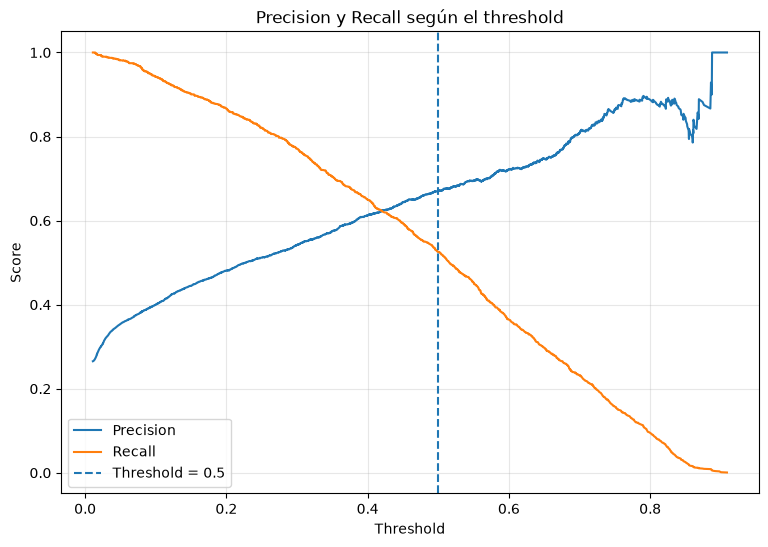

In [56]:
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    label="Recall"
)

plt.axvline(
    0.5,
    linestyle="--",
    label="Threshold = 0.5"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision y Recall según el threshold")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 9.4 Evaluación de thresholds candidatos

Dado que el objetivo de negocio concede especial importancia a reducir los falsos negativos, se analizan diferentes niveles mínimos de recall.

Para cada nivel objetivo se selecciona, entre los thresholds que alcanzan al menos dicho recall, aquel que proporciona la mayor precision.

Este procedimiento permite observar explícitamente qué pérdida de precision sería necesaria para incrementar la proporción de clientes con churn correctamente identificados.

In [57]:
target_recalls = [0.60, 0.65, 0.70, 0.75, 0.80]

threshold_candidates = []

for target_recall in target_recalls:

    candidates = threshold_results[
        threshold_results["Recall"] >= target_recall
    ]

    if not candidates.empty:

        best_candidate = candidates.loc[
            candidates["Precision"].idxmax()
        ]

        threshold_candidates.append({
            "Target Recall": target_recall,
            "Threshold": best_candidate["Threshold"],
            "Precision": best_candidate["Precision"],
            "Recall": best_candidate["Recall"]
        })

threshold_candidates = pd.DataFrame(threshold_candidates)

threshold_candidates

,Target Recall,Threshold,Precision,Recall
0,0.60,0.445828,0.639344,0.600000
1,0.65,0.399520,0.612720,0.650836
2,0.70,0.353038,0.576458,0.701003
3,0.75,0.314913,0.552231,0.753177
4,0.80,0.273967,0.525022,0.800000


### 9.5 Selección del threshold final

El análisis de las probabilidades out-of-fold muestra el trade-off existente entre precision y recall.

Con el threshold por defecto, el modelo prioriza una mayor precision pero identifica una proporción relativamente limitada de los clientes que realizan churn. Al reducir el threshold aumenta el número de clientes clasificados como posibles casos de churn y, en consecuencia, aumenta el recall a costa de una reducción de precision.

Dado que en el escenario de negocio planteado se considera más costoso un falso negativo que un falso positivo, se establece como criterio operativo identificar al menos aproximadamente el 75 % de los clientes que realizan churn.

Entre los thresholds que cumplen este requisito, se selecciona el que proporciona la mayor precision. Las predicciones out-of-fold sitúan este punto en un threshold aproximado de 0.315, con un recall de 0.753 y una precision de 0.552.

Esto supone aceptar un mayor número de falsos positivos a cambio de reducir de forma considerable los falsos negativos.

El nivel de recall del 75 % constituye una decisión de negocio planteada para este proyecto y no un óptimo económico demostrado, ya que el dataset no proporciona información sobre los costes reales asociados a falsos positivos y falsos negativos.

El threshold se fija utilizando exclusivamente información del conjunto de entrenamiento. Su capacidad de generalización se comprobará posteriormente sobre el conjunto de test reservado.

In [60]:
selected_threshold = threshold_candidates.loc[
    threshold_candidates["Target Recall"] == 0.75,
    "Threshold"
].iloc[0]

print(f"Threshold seleccionado: {selected_threshold:.4f}")

Threshold seleccionado: 0.3149


In [61]:
threshold_comparison = []

for threshold in [0.5, selected_threshold]:

    y_pred_oof = (
        y_train_oof_proba >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_train,
        y_pred_oof
    ).ravel()

    threshold_comparison.append({
        "Threshold": threshold,
        "Precision": precision_score(y_train, y_pred_oof),
        "Recall": recall_score(y_train, y_pred_oof),
        "F1": f1_score(y_train, y_pred_oof),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

threshold_comparison = pd.DataFrame(
    threshold_comparison
)

threshold_comparison

,Threshold,Precision,Recall,F1,TN,FP,FN,TP
0,0.500000,0.670077,0.525753,0.589205,3752,387,709,786
1,0.314913,0.552231,0.753177,0.637238,3226,913,369,1126


### 9.6 Comparación con el threshold por defecto

Para cuantificar el efecto del threshold seleccionado, se compara su comportamiento con el threshold por defecto de 0.5 utilizando las mismas predicciones out-of-fold.

Al reducir el threshold de 0.5 a aproximadamente 0.315, el recall aumenta de 0.526 a 0.753. En términos absolutos, el número de clientes con churn correctamente identificados aumenta de 786 a 1125, mientras que los falsos negativos disminuyen de 709 a 370.

Esta mejora en la detección de churn implica un coste en falsos positivos. Su número aumenta de 387 a 913 y, como consecuencia, la precision disminuye de 0.670 a 0.552.

Por tanto, el nuevo threshold permite detectar 339 casos adicionales de churn y evitar 339 falsos negativos, a cambio de generar 526 falsos positivos adicionales.

El F1-score también aumenta de 0.589 a 0.637. No obstante, este incremento no constituye el criterio utilizado para seleccionar el threshold, ya que la decisión se ha basado en alcanzar un recall mínimo aproximado del 75 % bajo el supuesto de que los falsos negativos tienen un mayor coste para el negocio.

La elección representa, por tanto, un compromiso operativo entre aumentar la detección de clientes con riesgo de abandono y mantener un nivel razonable de precision. Dado que no se dispone de información sobre los costes económicos reales de ambos tipos de error, el threshold seleccionado debe interpretarse como una decisión de negocio planteada para este proyecto y no como un óptimo económico demostrado.

## 10. Conclusiones del entrenamiento

Durante esta fase se han entrenado y comparado tres algoritmos de clasificación: Logistic Regression, Random Forest y XGBoost.

Los modelos se evaluaron mediante validación cruzada estratificada y posteriormente se optimizaron sus hiperparámetros utilizando Average Precision como criterio principal. Tras la optimización, XGBoost alcanzó el mayor Average Precision medio (0.669), aunque las diferencias respecto a Random Forest (0.663) y Logistic Regression (0.662) fueron reducidas.

Siguiendo el criterio definido previamente, XGBoost fue seleccionado como modelo para la fase final.

Posteriormente se analizaron diferentes thresholds utilizando probabilidades out-of-fold generadas exclusivamente a partir del conjunto de entrenamiento. Bajo el supuesto de negocio de que los falsos negativos tienen un coste mayor que los falsos positivos, se estableció como objetivo operativo alcanzar aproximadamente un 75 % de recall.

El threshold seleccionado fue aproximadamente 0.315. En las predicciones out-of-fold, este cambio incrementó el recall de 0.526 a 0.753 y redujo los falsos negativos de 709 a 370, a costa de aumentar los falsos positivos de 387 a 913 y reducir la precision de 0.670 a 0.552.

Tanto el modelo como el threshold han sido seleccionados sin utilizar el conjunto de test. En la siguiente fase se evaluará esta configuración sobre el conjunto de test reservado para obtener una estimación final de su capacidad de generalización.